# CALoRa Detection Rate vs SNR — Comparison Plot

Select which result CSV files to overlay on a single graph.

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

results_dir = os.path.join('.', 'results')

# List all available CSV files
all_csvs = sorted(glob.glob(os.path.join(results_dir, 'calora_results_*.csv')))
print(f'Available result files in {results_dir}:')
for i, f in enumerate(all_csvs):
    print(f'  [{i}] {os.path.basename(f)}')

Available result files in .\results:
  [0] calora_results_20260806_ori.csv
  [1] calora_results_20260806_ori_cfo.csv
  [2] calora_results_20260806_ori_sto.csv
  [3] calora_results_20260806_ori_sto_cfo.csv
  [4] calora_results_20260806_sean.csv
  [5] calora_results_20260806_sean_cfo.csv
  [6] calora_results_20260806_sean_sto.csv
  [7] calora_results_20260806_sean_sto_cfo.csv
  [8] calora_results_20260806_ys.csv
  [9] calora_results_20260806_ys_cfo.csv
  [10] calora_results_20260806_ys_sto.csv
  [11] calora_results_20260806_ys_sto_cfo.csv


In [73]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  EDIT HERE: specify the files you want to compare              ║
# ║  Use the exact filenames (without path) from the list above    ║
# ╚══════════════════════════════════════════════════════════════════╝

selected_files = [
    'conventional_results_20260806_101755.csv',
    'calora_results_20260806_ori.csv',
    'calora_results_20260806_sean.csv',
    'calora_results_20260806_ys.csv'
    
    # 'calora_results_XXXXXXXX_XXXXXX.csv',  # <-- add more here
]

# Optional: give each file a friendly label for the legend
# If left empty, the filename timestamp will be used
labels = [
    'Conventional',
    'CALoRa Baseline',
    'CALoRa training with my datasets',
    'CALoRa Yunsoeb latest weight'
    
    # 'Run 3',
]

# Verify files exist
for fname in selected_files:
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        print(f'⚠️  File not found: {path}')
    else:
        print(f'✅ {fname}')

✅ conventional_results_20260806_101755.csv
✅ calora_results_20260806_ori.csv
✅ calora_results_20260806_sean.csv
✅ calora_results_20260806_ys.csv


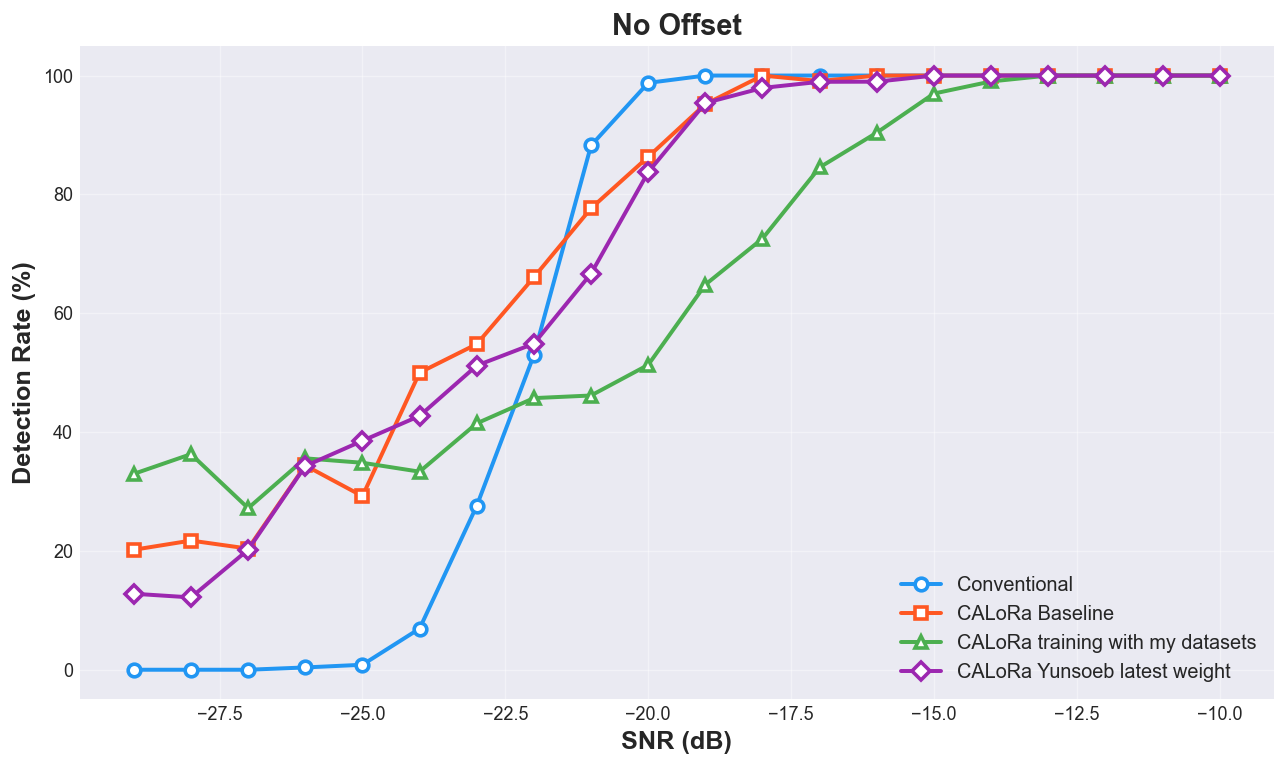


Plot saved to results/detrate_vs_snr_comparison.png


In [74]:
# ── Plot all selected files on one graph ─────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548']

for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        continue
    
    df = pd.read_csv(path).sort_values('SNR').reset_index(drop=True)
    
    # Use custom label or fallback to filename
    lbl = labels[i] if i < len(labels) and labels[i] else fname.replace('calora_results_', '').replace('.csv', '')
    
    ax.plot(
        df['SNR'], df['DetRate'],
        marker=markers[i % len(markers)],
        markersize=7, linewidth=2.2,
        color=colors[i % len(colors)],
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=colors[i % len(colors)],
        label=lbl
    )

ax.set_xlabel('SNR (dB)', fontsize=14, fontweight='bold')
ax.set_ylabel('Detection Rate (%)', fontsize=14, fontweight='bold')
ax.set_title('No Offset', fontsize=16, fontweight='bold')
ax.set_ylim(-5, 105)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'detrate_vs_snr_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\nPlot saved to results/detrate_vs_snr_comparison.png')

In [75]:
selected_files = [
    'conventional_results_20260806_cfo.csv',
    'calora_results_20260806_ori_cfo.csv',
    'calora_results_20260806_sean_cfo.csv',
    'calora_results_20260806_ys_cfo.csv'
    
    # 'calora_results_XXXXXXXX_XXXXXX.csv',  # <-- add more here
]

# Optional: give each file a friendly label for the legend
# If left empty, the filename timestamp will be used
labels = [
    'Conventional',
    'CALoRa Baseline',
    'CALoRa training with my datasets',
    'CALoRa Yunsoeb latest weight'
    
    # 'Run 3',
]

# Verify files exist
for fname in selected_files:
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        print(f'⚠️  File not found: {path}')
    else:
        print(f'✅ {fname}')

✅ conventional_results_20260806_cfo.csv
✅ calora_results_20260806_ori_cfo.csv
✅ calora_results_20260806_sean_cfo.csv
✅ calora_results_20260806_ys_cfo.csv


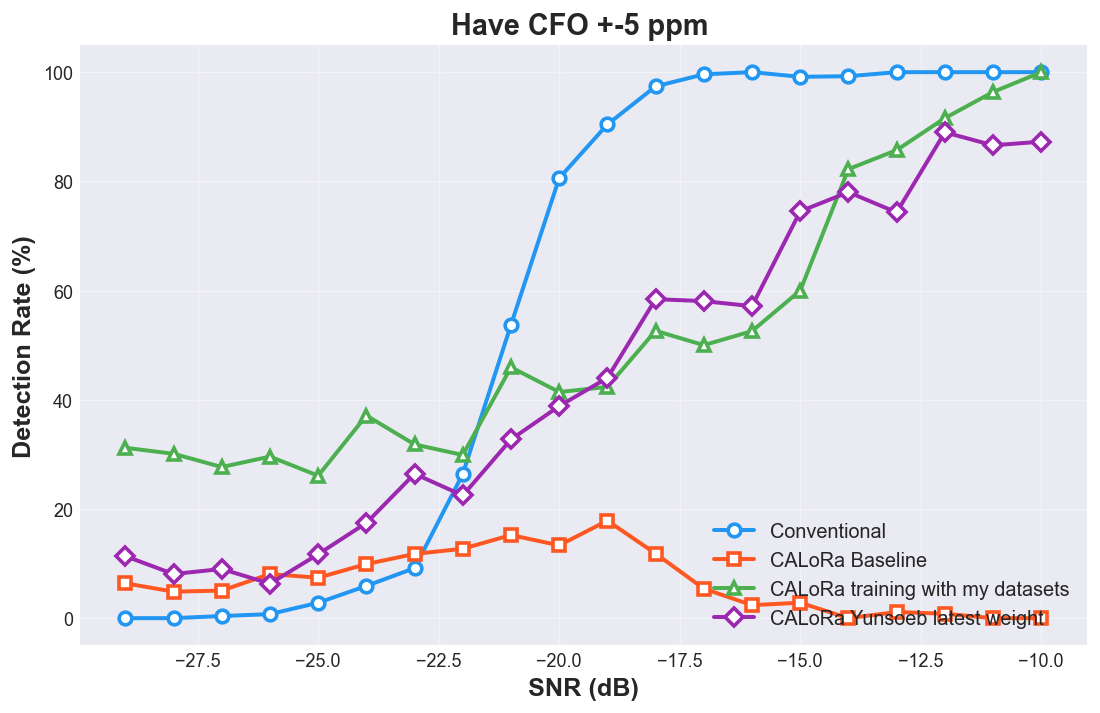

In [76]:
# ── Plot all selected files on one graph ─────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548']

for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        continue
    
    df = pd.read_csv(path).sort_values('SNR').reset_index(drop=True)
    
    # Use custom label or fallback to filename
    lbl = labels[i] if i < len(labels) and labels[i] else fname.replace('calora_results_', '').replace('.csv', '')
    
    ax.plot(
        df['SNR'], df['DetRate'],
        marker=markers[i % len(markers)],
        markersize=7, linewidth=2.2,
        color=colors[i % len(colors)],
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=colors[i % len(colors)],
        label=lbl
    )

ax.set_xlabel('SNR (dB)', fontsize=14, fontweight='bold')
ax.set_ylabel('Detection Rate (%)', fontsize=14, fontweight='bold')
ax.set_title('Have CFO  ', fontsize=16, fontweight='bold')
ax.set_ylim(-5, 105)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.4)

In [77]:
selected_files = [
    'conventional_results_20260806_sto.csv',
    'calora_results_20260806_ori_sto.csv',
    'calora_results_20260806_sean_sto.csv',
    'calora_results_20260806_ys_sto.csv'
    
    
    # 'calora_results_XXXXXXXX_XXXXXX.csv',  # <-- add more here
]

# Optional: give each file a friendly label for the legend
# If left empty, the filename timestamp will be used
labels = [
    'Conventional',
    'CALoRa Baseline',
    'CALoRa training with my datasets',
    'CALoRa Yunsoeb latest weight'
    
    # 'Run 3',
]

# Verify files exist
for fname in selected_files:
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        print(f'⚠️  File not found: {path}')
    else:
        print(f'✅ {fname}')

✅ conventional_results_20260806_sto.csv
✅ calora_results_20260806_ori_sto.csv
✅ calora_results_20260806_sean_sto.csv
✅ calora_results_20260806_ys_sto.csv


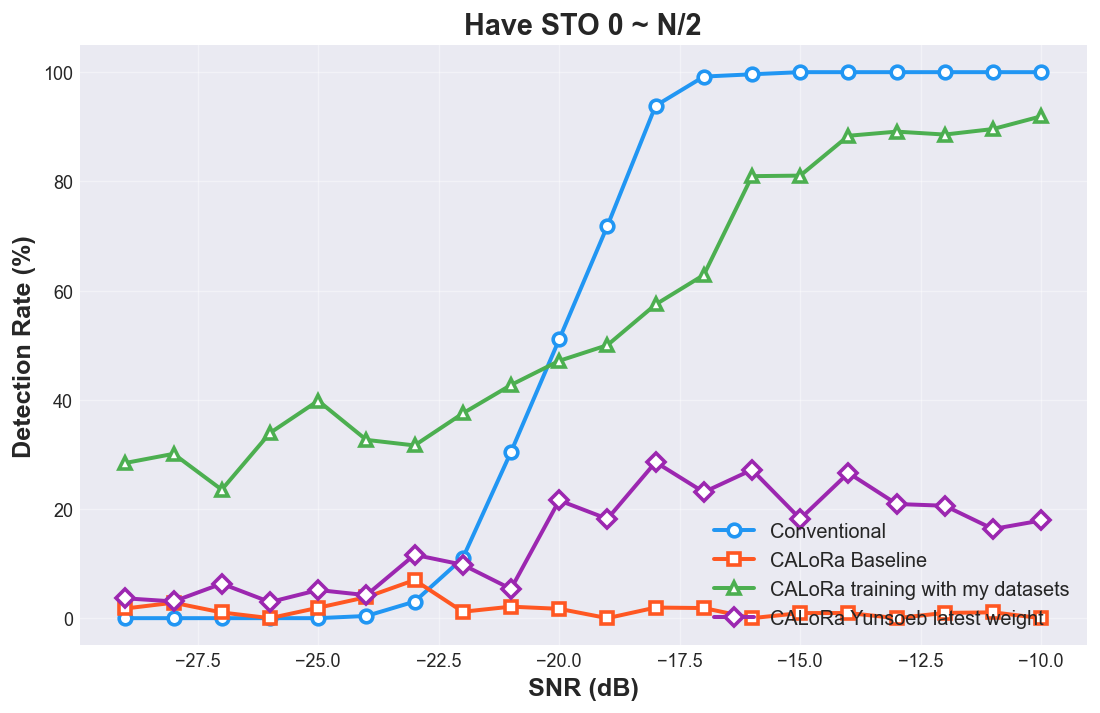

In [78]:
# ── Plot all selected files on one graph ─────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548']

for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        continue
    
    df = pd.read_csv(path).sort_values('SNR').reset_index(drop=True)
    
    # Use custom label or fallback to filename
    lbl = labels[i] if i < len(labels) and labels[i] else fname.replace('calora_results_', '').replace('.csv', '')
    
    ax.plot(
        df['SNR'], df['DetRate'],
        marker=markers[i % len(markers)],
        markersize=7, linewidth=2.2,
        color=colors[i % len(colors)],
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=colors[i % len(colors)],
        label=lbl
    )

ax.set_xlabel('SNR (dB)', fontsize=14, fontweight='bold')
ax.set_ylabel('Detection Rate (%)', fontsize=14, fontweight='bold')
ax.set_title('Have STO 0 ~ N/2', fontsize=16, fontweight='bold')
ax.set_ylim(-5, 105)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.4)

In [79]:
selected_files = [
    'conventional_results_20260806_sto_cfo.csv',
    'calora_results_20260806_ori_sto_cfo.csv',
    'calora_results_20260806_sean_sto_cfo.csv',
    'calora_results_20260806_ys_sto_cfo.csv'
    
    
    # 'calora_results_XXXXXXXX_XXXXXX.csv',  # <-- add more here
]

# Optional: give each file a friendly label for the legend
# If left empty, the filename timestamp will be used
labels = [
    'Conventional',
    'CALoRa Baseline',
    'CALoRa training with my datasets',
    'CALoRa Yunsoeb latest weight'
    # 'Run 3',
]

# Verify files exist
for fname in selected_files:
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        print(f'⚠️  File not found: {path}')
    else:
        print(f'✅ {fname}')

✅ conventional_results_20260806_sto_cfo.csv
✅ calora_results_20260806_ori_sto_cfo.csv
✅ calora_results_20260806_sean_sto_cfo.csv
✅ calora_results_20260806_ys_sto_cfo.csv


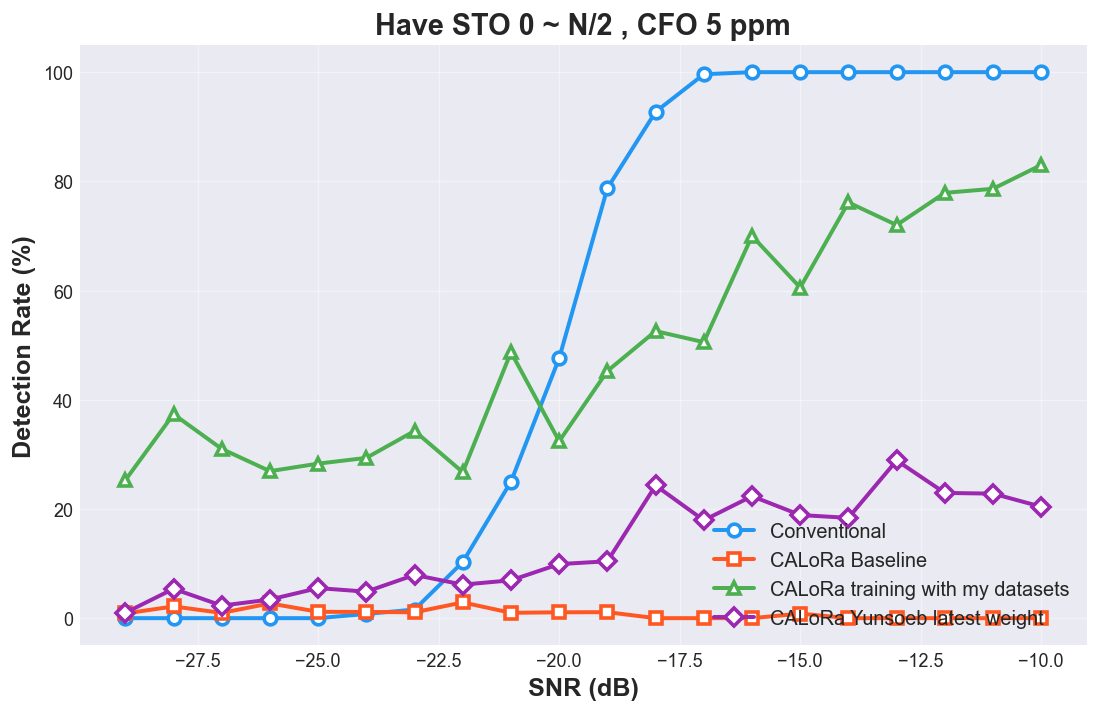

In [80]:
# ── Plot all selected files on one graph ─────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548']

for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        continue
    
    df = pd.read_csv(path).sort_values('SNR').reset_index(drop=True)
    
    # Use custom label or fallback to filename
    lbl = labels[i] if i < len(labels) and labels[i] else fname.replace('calora_results_', '').replace('.csv', '')
    
    ax.plot(
        df['SNR'], df['DetRate'],
        marker=markers[i % len(markers)],
        markersize=7, linewidth=2.2,
        color=colors[i % len(colors)],
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=colors[i % len(colors)],
        label=lbl
    )

ax.set_xlabel('SNR (dB)', fontsize=14, fontweight='bold')
ax.set_ylabel('Detection Rate (%)', fontsize=14, fontweight='bold')
ax.set_title('Have STO 0 ~ N/2 , CFO 5 ppm', fontsize=16, fontweight='bold')
ax.set_ylim(-5, 105)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.4)